In [27]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url="https://raw.githubusercontent.com/vega/vega/refs/heads/main/docs/data/seattle-weather.csv"
df = pd.read_csv(url)
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [5]:
df.shape

(1461, 6)

In [7]:
print("Dataset Columns: ", df.columns.tolist())
print("Data Types: ", df.dtypes)

Dataset Columns:  ['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']
Data Types:  date                 str
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather              str
dtype: object


In [8]:
#Check Missing Values
print(df.isnull().sum())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [22]:
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])
print(df['date'].head())

0   2012-01-01
1   2012-01-02
2   2012-01-03
3   2012-01-04
4   2012-01-05
Name: date, dtype: datetime64[us]


In [29]:
temp_array = np.array(df['temp_max'])

mean_temp = np.mean(temp_array)

#Standard Deviation
std_temp = np.std(temp_array)

z_scores = (temp_array - mean_temp) / std_temp if std_temp != 0 else 0

print("Mean Temperature:", mean_temp)
print("Standard Deviation:", std_temp)
print("First 5 Z-scores:", z_scores[:5])

Mean Temperature: 16.43908281998631
Standard Deviation: 7.347242349178532
First 5 Z-scores: [-0.49529914 -0.79473121 -0.64501518 -0.57696243 -1.02611054]


In [ ]:
#Extract Year and Month
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

In [26]:
#Calculate Temperature Range
df['temp_range'] = df['temp_max'] - df['temp_min']
print(df[['date', 'temp_max', 'temp_min', 'temp_range']].head())

        date  temp_max  temp_min  temp_range
0 2012-01-01      12.8       5.0         7.8
1 2012-01-02      10.6       2.8         7.8
2 2012-01-03      11.7       7.2         4.5
3 2012-01-04      12.2       5.6         6.6
4 2012-01-05       8.9       2.8         6.1


In [ ]:
#Avg Max Temperature by Month
monthly_temp = df.groupby('month')['temp_max'].mean()
print(monthly_temp)

month
1      8.229032
2      9.860177
3     12.387097
4     15.020000
5     19.295968
6     22.400000
7     25.998387
8     26.112097
9     21.924167
10    16.389516
11    11.023333
12     8.194355
Name: temp_max, dtype: float64


In [ ]:
#Avg Rainfall by Weather Condition
rain_analysis = df.groupby('weather')['precipitation'].mean()
print(rain_analysis)

weather
drizzle    0.000000
fog        0.000000
rain       6.557878
snow       8.553846
sun        0.000000
Name: precipitation, dtype: float64


In [ ]:
#Count of Weather Conditions
weather_count = df['weather'].value_counts()
print(weather_count)

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


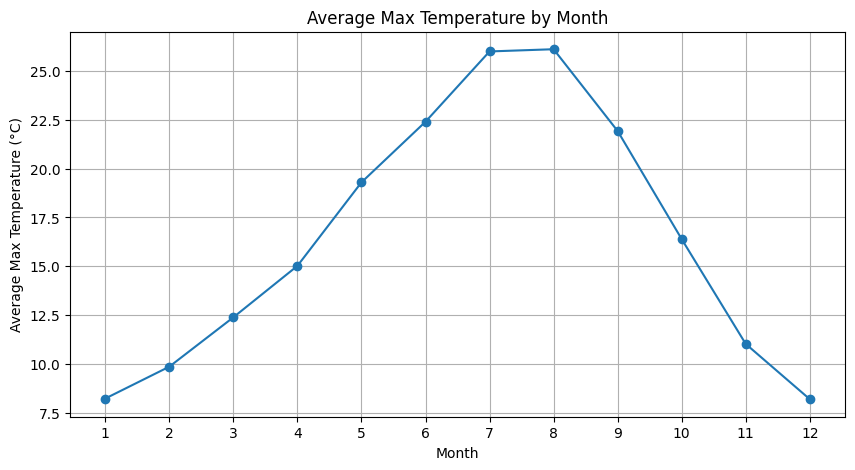

In [ ]:
#Monthly Temperature Trend
plt.figure(figsize=(10, 5))
monthly_avg_temp = df.groupby('month')['temp_max'].mean()
plt.plot(monthly_avg_temp.index, monthly_avg_temp.values, marker='o')
plt.title('Average Max Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Max Temperature (°C)')
plt.xticks(range(1, 13))
plt.grid()
plt.show()

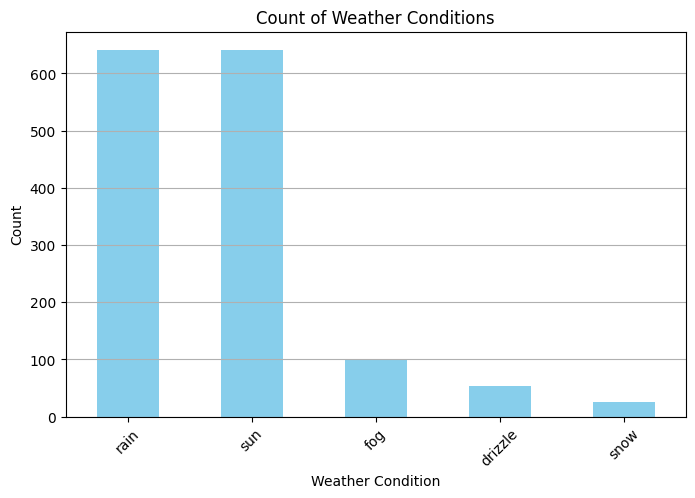

In [ ]:
#Weather Distribution Bar Chart
plt.figure(figsize=(8, 5))
weather_count.plot(kind='bar', color='skyblue')
plt.title('Count of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

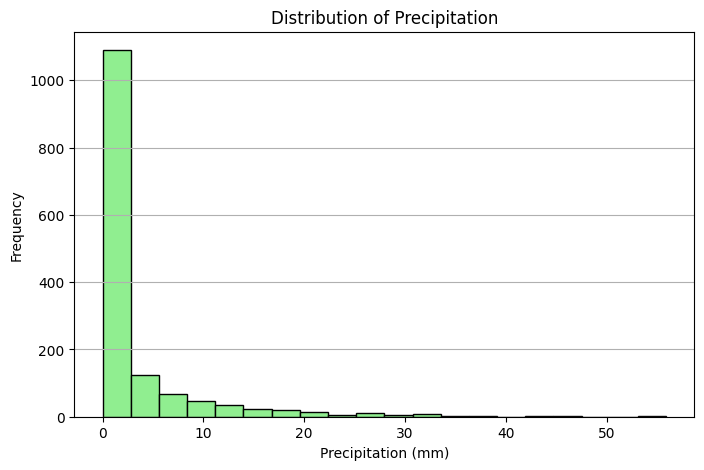

In [23]:
# Plot histogram to see distribution of precipitation
plt.figure(figsize=(8, 5))
plt.hist(df['precipitation'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Precipitation')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

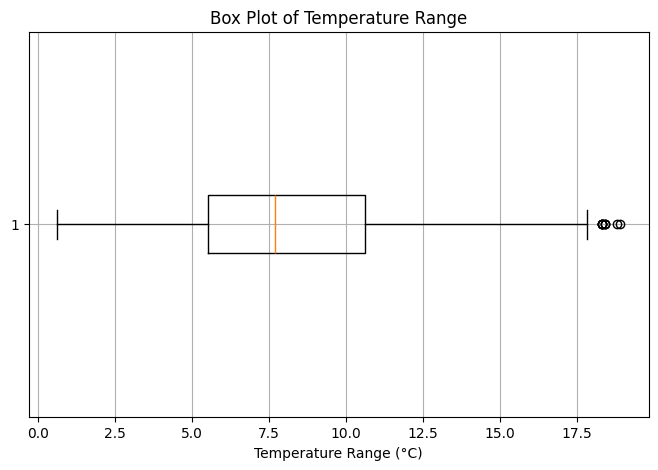

In [28]:
# Box plot of temperature range
plt.figure(figsize=(8, 5))
plt.boxplot(df['temp_range'], vert=False)
plt.title('Box Plot of Temperature Range')
plt.xlabel('Temperature Range (°C)')
plt.grid()
plt.show()

In [ ]:
# Save dataset

df.to_csv("processed_weather.csv", index=False)